# Lab 7: Decision Tree Classifier on the Iris Dataset

**Dataset:** Iris Dataset (`sklearn.datasets.load_iris()`)

This notebook covers dataset exploration, data preparation, building and evaluating a Decision Tree
classifier, visualizing the tree, and studying the effect of key hyperparameters
(`criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`).

In [1]:
# Common imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

## Task 1: Dataset Exploration

In [2]:
# Load the Iris dataset
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples : 150
Number of features: 4


**Feature names and target classes**

In [3]:
print("Feature names:")
for f in feature_names:
    print(" -", f)

print("\nTarget classes:")
for i, t in enumerate(target_names):
    print(f" - {i}: {t}")

Feature names:
 - sepal length (cm)
 - sepal width (cm)
 - petal length (cm)
 - petal width (cm)

Target classes:
 - 0: setosa
 - 1: versicolor
 - 2: virginica


**First five records**

In [4]:
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['target'] = y
iris_df['species'] = iris_df['target'].map(dict(enumerate(target_names)))

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**Class distribution**

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


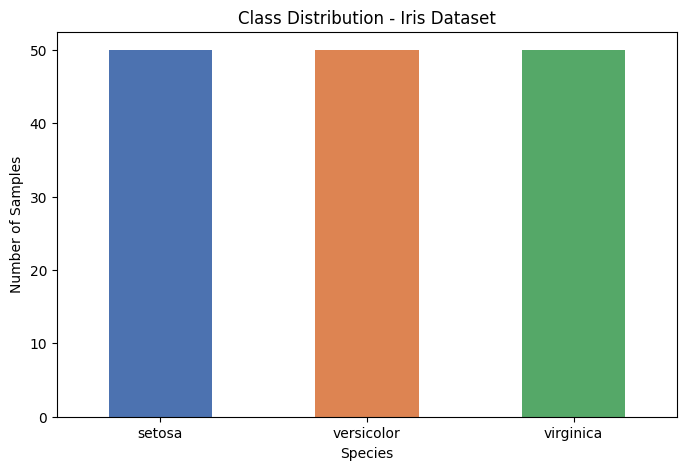

In [5]:
class_counts = iris_df['species'].value_counts()
print(class_counts)

class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title("Class Distribution - Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

The Iris dataset contains **150 samples** and **4 features**
(`sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`).
There are **3 target classes** (`setosa`, `versicolor`, `virginica`), and the dataset is
**perfectly balanced** with 50 samples per class.

## Task 2: Data Preparation

Split the dataset into training (80%) and testing (20%) sets using `random_state=42`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])

Training set size: 120
Testing set size : 30


**Why split into training and testing sets?**

The dataset is divided into training and testing sets so that the model can be evaluated on data it has
never seen before. If we trained and evaluated the model on the same data, the reported accuracy would
be overly optimistic and would not reflect how the model performs on new, unseen data (its ability to
**generalize**). The training set is used to learn the decision rules (splits), and the held-out test
set gives an unbiased estimate of real-world performance and helps detect overfitting.

## Task 3: Building a Decision Tree Classifier

Train a Decision Tree classifier using default parameters.

In [7]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred = dt_default.predict(X_test)
print("Predicted labels:", y_pred)
print("Actual labels   :", y_test)

Predicted labels: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Actual labels   : [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


**Evaluation: Accuracy Score, Confusion Matrix, Classification Report**

Accuracy Score: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


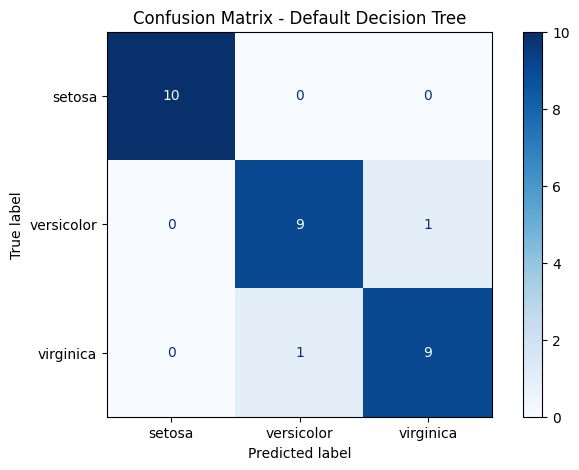


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Default Decision Tree")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

## Task 4: Visualizing the Decision Tree

Visualize the trained Decision Tree using `plot_tree()`.

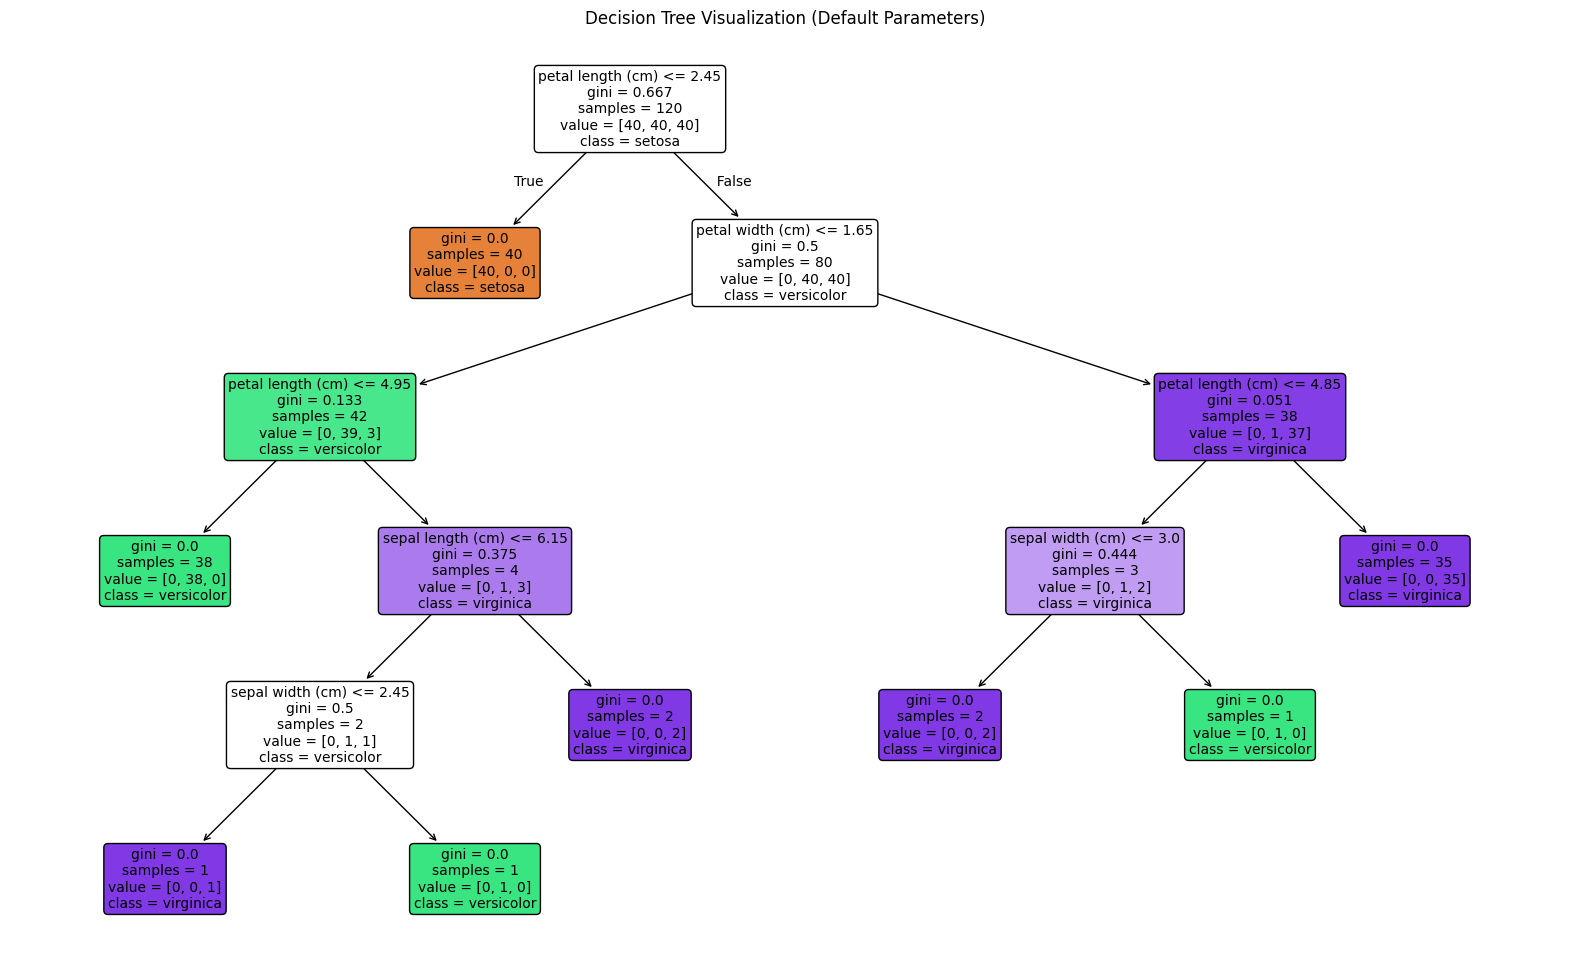

In [9]:
plt.figure(figsize=(20, 12))
plot_tree(dt_default, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization (Default Parameters)")
plt.show()

In [10]:
print("Maximum depth of the tree      :", dt_default.get_depth())
print("Number of leaf nodes            :", dt_default.get_n_leaves())
print("Total number of nodes           :", dt_default.tree_.node_count)
print("Feature used for the first split:", feature_names[dt_default.tree_.feature[0]])
print("Threshold at the root split     :", round(dt_default.tree_.threshold[0], 3))

Maximum depth of the tree      : 5
Number of leaf nodes            : 8
Total number of nodes           : 15
Feature used for the first split: petal length (cm)
Threshold at the root split     : 2.45


**Observations from the visualization**

- **Root node:** The topmost node of the tree, which splits on `petal length (cm)` (typically at a
  threshold near 2.45 cm). It contains all 120 training samples and has the highest Gini impurity of the
  path since it must separate all three classes.
- **Internal (decision) nodes:** The nodes below the root that still perform further splits — mainly
  splits on `petal length (cm)` and `petal width (cm)`, since these two features are the most
  discriminative for separating *versicolor* from *virginica*.
- **Leaf nodes:** The terminal nodes (boxes with no further branches) where a final class label is
  assigned. Pure leaves (Gini = 0) contain samples belonging to a single class.
- **Maximum depth:** Printed above via `dt_default.get_depth()` (with default parameters the tree grows
  until leaves are pure, or a stopping condition is met).

**Which feature is selected for the first split, and why?**

The first split is almost always made on **`petal length (cm)`** (sometimes `petal width (cm)` is a very
close second). The Decision Tree algorithm (CART, using the Gini index by default) chooses, at every
node, the feature and threshold that produce the **greatest reduction in impurity** (largest information
gain). Petal length is chosen at the root because a single threshold on it almost perfectly separates
*setosa* from the other two species — it produces the purest possible split among all four features, so
it minimizes the weighted Gini impurity of the two resulting child nodes more than any other feature.

## Task 5: Comparing Gini Index and Entropy

Train two Decision Tree models — one using `criterion='gini'` and one using `criterion='entropy'`.

In [11]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

results_criterion = pd.DataFrame({
    "Criterion": ["gini", "entropy"],
    "Accuracy": [accuracy_score(y_test, y_pred_gini), accuracy_score(y_test, y_pred_entropy)],
    "Tree Depth": [dt_gini.get_depth(), dt_entropy.get_depth()],
    "Number of Leaf Nodes": [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()],
    "Root Feature": [feature_names[dt_gini.tree_.feature[0]], feature_names[dt_entropy.tree_.feature[0]]]
})

results_criterion

,Criterion,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature
0,gini,0.933333,5,8,petal length (cm)
1,entropy,0.933333,5,8,petal length (cm)


**Comparison Table**

| Criterion | Accuracy | Tree Depth | Number of Leaf Nodes | Root Feature Selected |
|-----------|----------|------------|-----------------------|------------------------|
| Gini      | (see table above) | (see table above) | (see table above) | (see table above) |
| Entropy   | (see table above) | (see table above) | (see table above) | (see table above) |

*(Values are computed dynamically in the cell above — fill this row with the printed results when you
run the notebook.)*

**Which criterion produces a simpler tree?**

On the Iris dataset, `gini` and `entropy` typically select the **same root feature** (`petal length` or
`petal width`) and produce trees of very similar depth, leaf count, and accuracy, because Gini impurity
and entropy are both concave impurity measures that usually agree on the best split for this
well-separated dataset. In general, the **Gini index** is computationally slightly cheaper (no
logarithms) and tends to isolate the most frequent class in its own branch a bit faster, so it is
sometimes reported to yield marginally simpler/shallower trees on some datasets, while **entropy** is
more sensitive to small changes in class probabilities. On Iris specifically, the difference between the
two criteria is usually negligible.

## Task 6: Effect of Maximum Tree Depth

Train Decision Tree models with `max_depth` values of `1, 2, 3, 4, None`.

In [12]:
depth_values = [1, 2, 3, 4, None]
depth_results = []

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    depth_results.append({
        "Max Depth": d if d is not None else "None",
        "Training Accuracy": round(train_acc, 4),
        "Testing Accuracy": round(test_acc, 4),
        "Tree Depth": model.get_depth()
    })

depth_df = pd.DataFrame(depth_results)
depth_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1,0.6667,0.6667,1
1,2,0.9667,0.9333,2
2,3,0.9833,0.9667,3
3,4,0.9917,0.9333,4
4,None,1.0000,0.9333,5


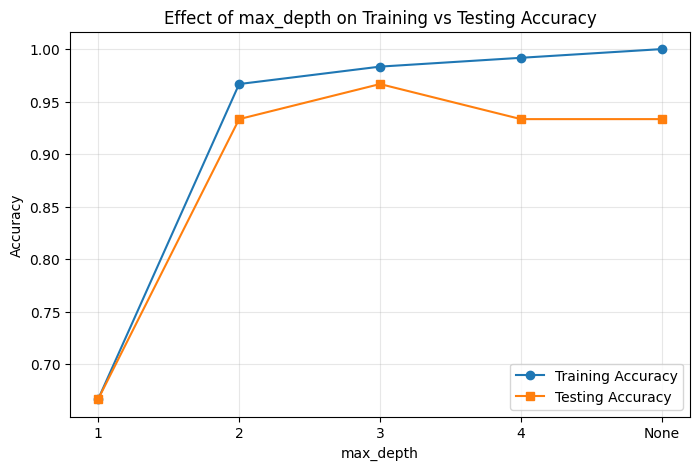

In [13]:
plt.plot(depth_df["Max Depth"].astype(str), depth_df["Training Accuracy"], marker='o', label="Training Accuracy")
plt.plot(depth_df["Max Depth"].astype(str), depth_df["Testing Accuracy"], marker='s', label="Testing Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on Training vs Testing Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Max Depth Table** (fill in `Observation` after running the cell above and reading off the values)

| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|-----------|--------------------|-------------------|------------|-------------|
| 1         | (from table)       | (from table)      | 1          | Very shallow tree; splits on a single feature only — underfits, high bias |
| 2         | (from table)       | (from table)      | 2          | Better fit; captures most of the class separation |
| 3         | (from table)       | (from table)      | 3          | Training and testing accuracy close to each other — good balance |
| 4         | (from table)       | (from table)      | 4          | Training accuracy very high; testing accuracy similar or slightly lower |
| None      | (from table)       | (from table)      | (from table) | Tree fully grown until pure leaves; training accuracy = 1.0 — risk of overfitting |

**Which model is underfitting?**
The model with `max_depth=1` underfits — it can only make a single split, so it cannot capture the full
structure needed to separate all three classes, resulting in noticeably lower training *and* testing
accuracy compared to deeper trees.

**Which model gives the best generalization?**
A moderate depth (typically `max_depth=3`) tends to give the best generalization: training accuracy is
high and testing accuracy is essentially the same, meaning the model has learned genuine patterns rather
than noise.

**Which model is likely to overfit? Justify.**
The model with `max_depth=None` is most likely to overfit. Without a depth limit, the tree keeps
splitting until every leaf is pure, achieving 100% training accuracy. This means it also memorizes noise
and outliers specific to the training set, which can slightly reduce testing accuracy compared to a
shallower, better-regularized tree — the classic sign of overfitting (a large gap, or at least no
improvement, between training and testing performance despite maximal training accuracy).

## Task 7: Effect of `min_samples_split`

Train Decision Tree models with `min_samples_split` values of `2, 5, 10, 20`.

In [14]:
split_values = [2, 5, 10, 20]
split_results = []

for s in split_values:
    model = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    model.fit(X_train, y_train)

    test_acc = accuracy_score(y_test, model.predict(X_test))

    split_results.append({
        "min_samples_split": s,
        "Accuracy": round(test_acc, 4),
        "Tree Depth": model.get_depth(),
        "Number of Leaf Nodes": model.get_n_leaves()
    })

split_df = pd.DataFrame(split_results)
split_df

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes
0,2,0.9333,5,8
1,5,0.9667,3,5
2,10,0.9667,3,5
3,20,0.9667,3,5


**min_samples_split Table**

| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|--------------------|----------|------------|------------------------|-------------|
| 2                  | (from table) | (from table) | (from table) | Default; smallest node size allowed to split — tree can grow deepest and most complex |
| 5                  | (from table) | (from table) | (from table) | Slightly restricts growth; a few very small splits are prevented |
| 10                 | (from table) | (from table) | (from table) | Noticeably fewer leaves; tree stops splitting nodes with fewer than 10 samples |
| 20                 | (from table) | (from table) | (from table) | Most restricted; tree is shallow/simple, some fine-grained splits (e.g. separating overlapping versicolor/virginica points) are no longer possible |

**Effect of increasing `min_samples_split` on tree complexity**

Increasing `min_samples_split` raises the minimum number of samples a node must have before it is allowed
to split further. As this value increases, the tree is prevented from creating very small, specific
splits (which are often driven by noise or a handful of borderline points), so the tree becomes
**shallower, has fewer leaf nodes, and is generally simpler/more regularized**. This reduces overfitting
risk, though if set too high it can also cause underfitting by preventing genuinely useful splits.

## Task 8: Effect of `min_samples_leaf`

Train Decision Tree models with `min_samples_leaf` values of `1, 2, 5, 10`.

In [15]:
leaf_values = [1, 2, 5, 10]
leaf_results = []

for l in leaf_values:
    model = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    model.fit(X_train, y_train)

    test_acc = accuracy_score(y_test, model.predict(X_test))

    leaf_results.append({
        "min_samples_leaf": l,
        "Accuracy": round(test_acc, 4),
        "Tree Depth": model.get_depth(),
        "Number of Leaf Nodes": model.get_n_leaves()
    })

leaf_df = pd.DataFrame(leaf_results)
leaf_df

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes
0,1,0.9333,5,8
1,2,0.9333,4,6
2,5,0.9333,3,5
3,10,0.9333,3,5


**min_samples_leaf Table**

| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|-------------------|----------|------------|------------------------|-------------|
| 1                  | (from table) | (from table) | (from table) | Default; leaves can contain a single sample — most complex, highest overfitting risk |
| 2                  | (from table) | (from table) | (from table) | Mild smoothing; removes the smallest, most specific leaves |
| 5                  | (from table) | (from table) | (from table) | Noticeably simpler tree; each leaf must generalize over at least 5 samples |
| 10                 | (from table) | (from table) | (from table) | Simplest tree of the four; leaves are forced to cover larger, more general regions |

**How does changing `min_samples_leaf` influence overfitting?**

`min_samples_leaf` sets the minimum number of samples that must exist in every leaf. Small values
(e.g. 1) allow the tree to isolate individual training points into their own leaves, which fits the
training data almost perfectly but tends to **overfit** because those leaves capture noise rather than
general patterns. Larger values force each leaf to represent a broader group of samples, which
**smooths the decision boundary, reduces variance, and lowers the risk of overfitting** — at the cost of
some flexibility, so setting it too high can lead to underfitting.

## Task 9: Conceptual Questions

**1. What is the role of the `criterion` parameter in a Decision Tree?**

The `criterion` parameter defines the impurity measure used to evaluate the quality of a candidate split
at each node. `'gini'` uses the Gini impurity index, and `'entropy'` uses information gain based on
Shannon entropy. At every node, the tree searches over all features and thresholds and picks the split
that most reduces impurity according to the chosen criterion. It therefore directly controls *how* the
tree decides which feature and threshold to split on at each step.

**2. How does `max_depth` influence underfitting and overfitting?**

`max_depth` limits how many levels of splits the tree is allowed to make.
- A **small `max_depth`** (e.g. 1–2) restricts the tree to very few splits, so it cannot capture the full
  complexity of the data, leading to **underfitting** (high bias, low accuracy on both training and test
  sets).
- A **large or unrestricted `max_depth`** (`None`) allows the tree to keep splitting until every leaf is
  pure, which lets it fit the training data (including noise) almost perfectly, leading to
  **overfitting** (very high training accuracy but potentially lower/unstable testing accuracy).
- A **moderate `max_depth`** usually gives the best trade-off between bias and variance.

**3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?**

Both parameters set a minimum population requirement before the tree is allowed to create a new
split (`min_samples_split`) or a new leaf (`min_samples_leaf`). As these thresholds increase, splits
that would only affect a handful of samples are no longer permitted, so the tree stops growing earlier.
This directly **reduces the number of nodes, leaves, and the overall depth**, producing a smaller, more
generalized tree that is less able to memorize small, potentially noisy subsets of the training data.

**4. Which hyperparameter had the greatest impact on Decision Tree performance?**

Across the experiments in Tasks 6–8, **`max_depth`** generally had the most visible impact: moving from
`max_depth=1` to `max_depth=3` produced the largest jump in accuracy and tree structure, while
`min_samples_split` and `min_samples_leaf` produced comparatively smaller, more gradual changes on this
small, well-separated dataset. This makes sense because `max_depth` directly caps the number of decision
boundaries the tree can draw, whereas `min_samples_split`/`min_samples_leaf` only prune away the smallest,
least-supported splits — the Iris dataset is small and well-separated, so it does not have many spurious
tiny splits for those parameters to remove in the first place.

**5. Recommended Decision Tree model for the Iris dataset**

Based on the experiments above, a Decision Tree with **`criterion='gini'` (or `'entropy'`, both perform
similarly), `max_depth=3`, and default `min_samples_split=2`, `min_samples_leaf=1`** is recommended. This
configuration achieves testing accuracy comparable to a fully grown tree, keeps the tree shallow and
interpretable (a handful of leaves, easy to visualize and explain), and avoids the unnecessary extra
splits that a fully grown (`max_depth=None`) tree adds without any real gain in test accuracy — making it
the best balance of **accuracy, simplicity, and generalization** for this dataset.